In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
train_dir = "/content/drive/MyDrive/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/FruitinAmazon/test"

In [7]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

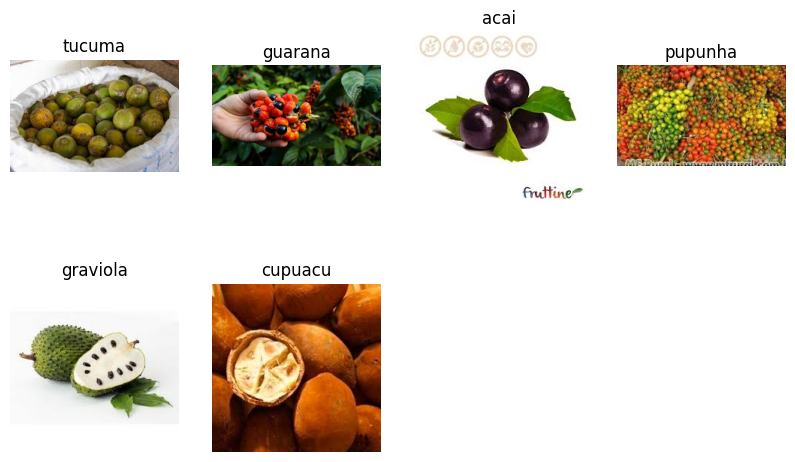

In [9]:
classes = os.listdir(train_dir)

images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append((img, cls))

plt.figure(figsize=(10,6))

for i, (img, label) in enumerate(images):
    plt.subplot(2, len(images)//2 + 1, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.show()

In [10]:
from PIL import Image

def remove_corrupted_images(folder):
    corrupted = []

    for cls in os.listdir(folder):
        class_path = os.path.join(folder, cls)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()
            except:
                print(f"Removed: {img_path}")
                os.remove(img_path)
                corrupted.append(img_path)

    if len(corrupted) == 0:
        print("No Corrupted Images Found.")

remove_corrupted_images(train_dir)
remove_corrupted_images(test_dir)

No Corrupted Images Found.
No Corrupted Images Found.


In [11]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 16

# Train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=123
)

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=123
)

# Test dataset (separate)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


In [12]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

In [13]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.1580 - loss: 2.7434

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 396ms/step - accuracy: 0.1389 - loss: 2.7906 - val_accuracy: 0.1111 - val_loss: 1.9411
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.1514 - loss: 1.7863

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - accuracy: 0.1944 - loss: 1.8037 - val_accuracy: 0.1111 - val_loss: 1.8734
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.2403 - loss: 1.7602

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 339ms/step - accuracy: 0.3056 - loss: 1.7273 - val_accuracy: 0.1667 - val_loss: 1.7972
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 375ms/step - accuracy: 0.6111 - loss: 1.5971 - val_accuracy: 0.1667 - val_loss: 1.7973
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 634ms/step - accuracy: 0.6944 - loss: 1.3128 - val_accuracy: 0.2222 - val_loss: 1.8752
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 547ms/step - accuracy: 0.6667 - loss: 1.0209 - val_accuracy: 0.2778 - val_loss: 1.8377
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 357ms/step - accuracy: 0.7639 - loss: 0.8166 - val_accuracy: 0.2778 - val_loss: 1.9031
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.8972 - loss: 0.5303

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 390ms/step - accuracy: 0.8611 - loss: 0.5541 - val_accuracy: 0.3333 - val_loss: 1.7094
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - accuracy: 0.9861 - loss: 0.3255 - val_accuracy: 0.2778 - val_loss: 2.1574
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 335ms/step - accuracy: 1.0000 - loss: 0.1702 - val_accuracy: 0.3333 - val_loss: 1.7935
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 425ms/step - accuracy: 1.0000 - loss: 0.1073 - val_accuracy: 0.4444 - val_loss: 1.7537
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 544ms/step - accuracy: 1.0000 - loss: 0.0408 - val_accuracy: 0.4444 - val_loss: 2.5031
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 764ms/step - accuracy: 1.0000 - loss: 0.0221 - val_accuracy: 0.2778 - val_loss: 2.1278
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 431ms/step - accuracy: 1.0000 - loss: 0.0194 - val_accuracy: 0.4444 - val_loss: 1.9672
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 806ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 0.5000 - val_los

In [16]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6000 - loss: 1.0051
Test Accuracy: 0.6000000238418579


In [17]:
model.save("cnn_model.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("cnn_model.h5")

In [18]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.40      0.80      0.53         5
    graviola       0.83      1.00      0.91         5
     guarana       0.50      0.20      0.29         5
     pupunha       0.75      0.60      0.67         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.60        30
   macro avg       0.62      0.60      0.58        30
weighted avg       0.62      0.60      0.58        30



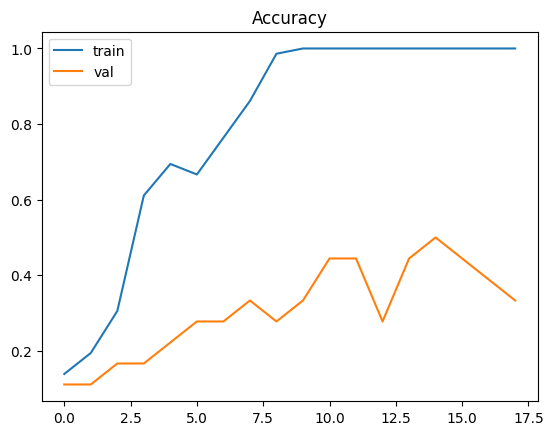

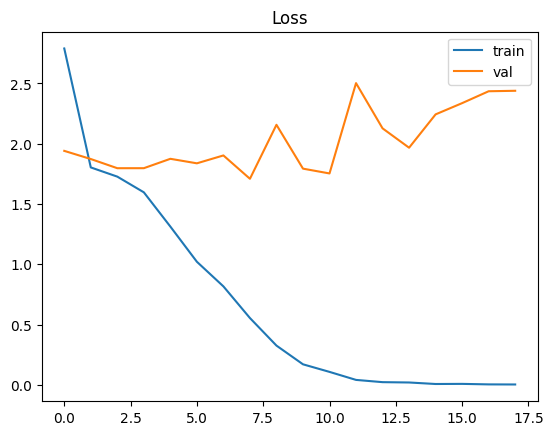

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()